# Module Overview: Bigram to Transformer

Here I'm trying to implement a character-level bigram language model, intended as a precursor to developing modern Transformer architectures like GPT.

**The primary objectives are:**

1.  **Tensor Manipulation**
    * Exploring the nuances of `torch.Tensor` to optimize neural network performance.

2.  **Modeling Framework**
    * Establishing a robust framework for language modeling that encompasses:
        * Model training
        * Data sampling
        * Loss evaluation (via negative log likelihood)


**Current implementation follows a few key papers:**

- Bigram (one character predicts the next one with a lookup table of counts)
- MLP, following Bengio et al. 2003
- CNN, following DeepMind WaveNet 2016 (in progress...)
- RNN, following Mikolov et al. 2010
- LSTM, following Graves et al. 2014
- GRU, following Kyunghyun Cho et al. 2014
- Transformer, following Vaswani et al. 2017


# Part1: Bigram

## Load up the dataset

In [ ]:
words = open('names.txt','r').read().splitlines()

In [ ]:
words[:10]

In [ ]:
len(words)

In [ ]:
min(len(w) for w in words)

In [ ]:
max(len(w) for w in words)

A character level language model is predicting the next character in a sequence given already some concrete sequence of characters before it.

In order to learn the statistic about which chars are likely to follow other chars, the simplest way in the bigram language models is to do it by counting.
Count how ofter any one of these combinations occurs in the training set.

In [ ]:
# start with checking the bi-grams(2 char) in datasets
# a dictionary to maintain the counts for every of these bigrams
b = {}
for w in words:
    chs = ['<S>'] + list(w)+['<E>'] # special char to note the Start and End
    # for ch1, ch2 in zip(w,w[1:]): # w = emma; w[1:] = mma
    for ch1, ch2 in zip(chs,chs[1:]):
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) +1
        #print(ch1, ch2)

In [ ]:
list(w)

In [ ]:
sorted(b.items(), key = lambda kv: -kv[1])

It'll be more convenient to keep the infos in a 2D array instead of a dictionary. 

2D array, rows: 1st char of the bigram, columns: 2nd char of the bigram, entry: how often this 2nd char follows this 1st char

In [ ]:
# use pytorch to achieve this
import torch

In [ ]:
N = torch.zeros((28, 28), dtype=torch.int32)
#because of a word can never have a char after <E> nor a char before <S>, there are some columns and lines not needed
N = torch.zeros((27, 27), dtype=torch.int32)


In [ ]:
chars = sorted(list(set(''.join(words)))) # "''.join(words)": concatenate all words in dataset together -> set(): remove doubels -> list(): convert into list -> sorted(): a to z in order 
stoi = {s:i+1 for i, s in enumerate(chars)} # string to integer lookup table
#stoi['<S>'] = 26
#stoi['<E>'] = 27
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}

In [ ]:
# to store this, we need a look-up table to convert char into int
for w in words:
    chs = ['.'] + list(w)+['.']
    for ch1, ch2 in zip(chs,chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1

       

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.imshow(N)

In [ ]:
# better way to visulize
plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off')

In [ ]:
N[0]

we need to sample from this table, to convert the number into probabilities

In [ ]:
# create a probability vector
p = N[0].float() # convert to float in order to normalize the counts, to create a probability distribution
p = p / p.sum() # probability of each count
p.sum() # = 1

Use storch.multinominal to sample from these distributions + generator

In [ ]:
g = torch.Generator().manual_seed(2147483647)
p = torch.rand(3, generator=g) # generate 3 random numbers between 0 and 1
p = p / p.sum()
p

In [ ]:
torch.multinomial(p, num_samples=100, replacement=True, generator=g)

### Understanding `torch.multinomial`

This line performs **weighted random sampling**. It uses the probabilities calculated in `p` to select indices.

```python
torch.multinomial(p, num_samples=20, replacement=True, generator=g)
```

* **`p` (The Input):**
  This is the tensor of probabilities you just created (e.g., `[0.6, 0.3, 0.1]`). PyTorch views these as "weights." Index 0 has a 60% chance of being picked, Index 1 has 30%, and Index 2 has 10%.

* **`num_samples=20`:**
  This tells PyTorch to generate 20 results. You are essentially rolling a die (or spinning a spinner) 20 times.

* **`replacement=True` (Crucial Step):**
  * **`True`:** This means "put the ball back in the bag after you pick it." You can pick the same index multiple times. This is strictly necessary here because you are asking for 20 samples from a list of only 3 items.
  * **`False`:** You would pick an item and remove it. (This would crash here because you cannot pick 20 unique items from a list of 3).

* **`generator=g`:**
  Just like before, this ensures the random draws are the exact same every time you run the code.

Now in p we have0.6064, 0.3033 and 0.0903 so when we use it to normalize, we'll have among the 20 samples, almost 60% of 0, 30% of 1 and 10% of 2

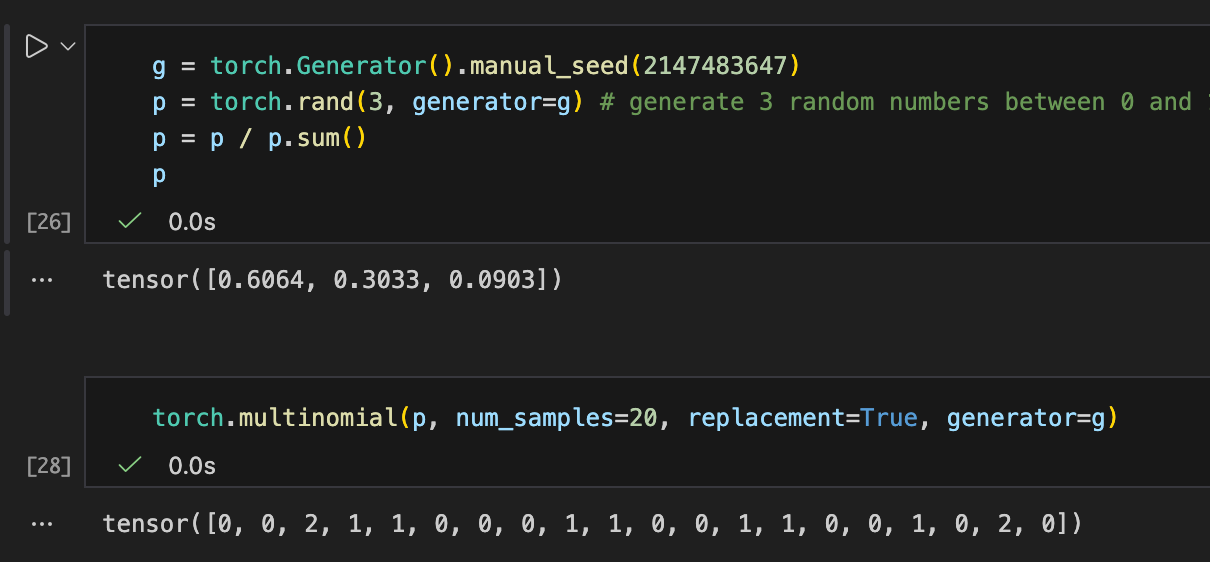

In [ ]:
g = torch.Generator().manual_seed(2147483647)
p = torch.rand(3, generator=g)
p = p / p.sum()
ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
itos[ix]

In [ ]:
g = torch.Generator().manual_seed(2147483647)

for i in range(20):
    out = []
    ix = 0
    while True:
        p = P[ix] # run the next Python block first before using this line
        #p = N[ix].float()
        #p = p / p.sum()
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0 :
            break
    print(''.join(out))

### Bigram Generation Code Explanation

This code uses the statistical counts stored in matrix `N` to generate 20 new sequences ("names") that mimic the patterns in the training data.

#### Step 1: Setup and Outer Loop
* **`manual_seed`:** Sets a fixed seed for the random number generator. This ensures the code produces the exact same results every time it is run.

* **`for i in range(20)`:** We want to generate 20 different examples, so we loop 20 times.

* **`ix = 0`:** We initialize the "current state" to index 0. In this model, 0 represents the special start/end character (usually .).

#### Step 2: Calculating Probabilities (Inside the Loop)
* **`N[ix]`:** The code looks up the row in the matrix corresponding to the current character ix. This row contains the raw counts of which characters have historically followed the current one.

* **`Normalization`:** We divide the raw counts by their total sum. This converts the counts into probabilities (a list of numbers between 0 and 1 that sum up to 1.0).

#### Step 3: Sampling the Next Character
* **`torch.multinomial`:** This acts like spinning a weighted wheel. It randomly picks the index of the next character based on the probabilities calculated in Step 2.

* **`item()`:** This extracts the single integer value (e.g., 5) from the PyTorch tensor so it can be used as a standard number.

* **`State Update`:** The variable ix is updated to this new index. The character we just picked becomes the "current character" for the next iteration.

#### Step 4: Storing, Stopping, and Printing
* **`out.append`:** We convert the integer index back into a character string (using the itos dictionary) and add it to our list of characters.

* **`if ix == 0`:** We check if the newly sampled character is the special End Token (0 or .). If it is, the word is finished, and we break the infinite loop.

* **`print`:** Finally, we join the list of characters into a single string and print the generated word.

## efficiency

**`torch.sum(input, dim, keepdim=False, *, dtype=None) → Tensor`**
Returns the sum of each row of the input tensor in the given dimension dim. If dim is a list of dimensions, reduce over all of them.

If `keepdim` is `True`, the output tensor is of the same size as `input` except in the dimension(s) `dim` where it is of size 1. Otherwise, `dim` is squeezed (see torch.squeeze()), resulting in the output tensor having 1 (or `len(dim)`) fewer dimension(s).

In [ ]:
# to solve the probrlem of efficiency
# instead of p = N[ix].float() and p = p / p.sum() we'll just use p = P[ix]
# this matrix P will hold probabilities inside, it's somehow like N but every row will have the row of probabilities that is normalized to 1, 
# indicating the probability distribution for the next char given the char before it. 
P = N.float() 
P.sum(1, keepdim=True)
P /= P.sum(1, keepdim=True)

In [ ]:
P[0].sum() # = 1
# now use P inside the bigram generattion code

## Evaluate the quality of the model(loss function)

The method we use here is called **`log likelihood`**

In [ ]:
# log(a*b*c) = log(a)+log(b)+log(c)
log_likelihood = 0.0
n = 0
for w in words:
    chs = ['.'] + list(w)+['.']
    for ch1, ch2 in zip(chs,chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        n += 1
        #print(f'{ch1}{ch2}: {prob:.4f}{logprob:.4f}')

print(f'{log_likelihood=}')
nll = -log_likelihood # negative likelihood
print(f'{nll=}') # a very good way to show result, the loss
print(f'{nll/n=}') # a nomalized likelihood 
# nll/n usually the loss function here, for the training set assigned by the model is 2.4, the quality of this model, the lower the better

### **`GOAL`**: maximize likelihood of the data w.r.t. model parameters (statistical modeling)
**`==>`** maximizing the log likelihood (because log is monotonic)

**`==>`** minimizing the negative log likelihood

**`==>`** minimizing the average negative log likelihood

Work to do: find the parameters that minimize the **`negative log likelihood loss`**

### Model smoothing with fake counts

In [ ]:
P = (N+1).float() # the number added to N can smooth the model, the less you add, the more peaked model you'll get
                # so even a bigram of which the probability was 0, which in nll will cause infinity, now it will have a log value that is very small but not negative infinity
P.sum(1, keepdim=True)
P /= P.sum(1, keepdim=True)

# Part2: Neural Network approach
#### Cast the problem of bi-gram character level language modeling into the neural network framework, end up in a similar position

We're going to use gradient-based optimization to tune the parameters fo this network.

Minimize the loss function --> tune the weights --> neural network predicts the probability correctly for the next char

In [ ]:
# create the training set of bigrams (x,y)
xs,ys = [],[] # inputs and targets(labels)

for w in words[:1]:
    chs = ['.'] + list(w)+['.']
    for ch1, ch2 in zip(chs,chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        print(ch1, ch2)
        xs.append(ix1)
        ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)

In [ ]:
xs

In [ ]:
ys

when the input(index) is 0, we want the output-is-5's probability to be high

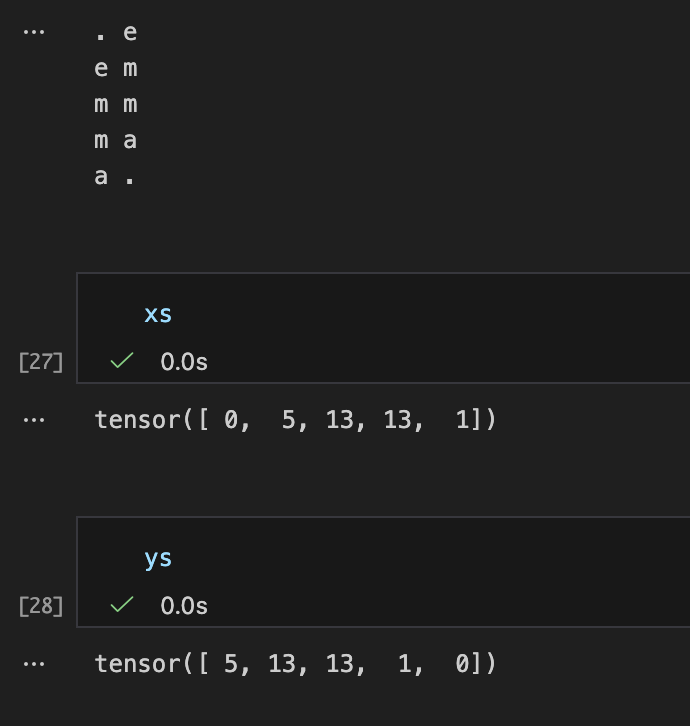

## Feeding integers into neural nets, one-hot encoding

encode integers: one-hot encoding, take an integer x and create a vector that is all zeros except for the xth dimension turning to 1, feed this vector into a neural net

# torch.nn.functional.one_hot

**`torch.nn.functional.one_hot(tensor, num_classes=-1)`** → **`LongTensor`**

Takes LongTensor with index values of shape `(*)` and returns a tensor of shape `(*, num_classes)` that have zeros everywhere except where the index of last dimension matches the corresponding value of the input tensor, in which case it will be 1.

**Parameters:**

* **tensor** (*LongTensor*) – class values of any shape.
* **num_classes** (*int, optional*) – Total number of classes. If set to -1, the number of classes will be inferred as one greater than the largest class value in the input tensor. Default: -1

**Returns:**

LongTensor that has one more dimension with 1 values at the index of last dimension indicated by the input, and 0 everywhere else.

In [ ]:
import torch.nn.functional as F
xenc = F.one_hot(xs, num_classes=27).float() # xenc: x encoded
                                            # we want the dtype to be float instead of int
xenc.shape

In [ ]:
plt.imshow(xenc)

In [ ]:
xenc.dtype

Construct the first neuron.

With torch.randn, it takes most of the numbers around 0, some will be around 3, but very few from above 3

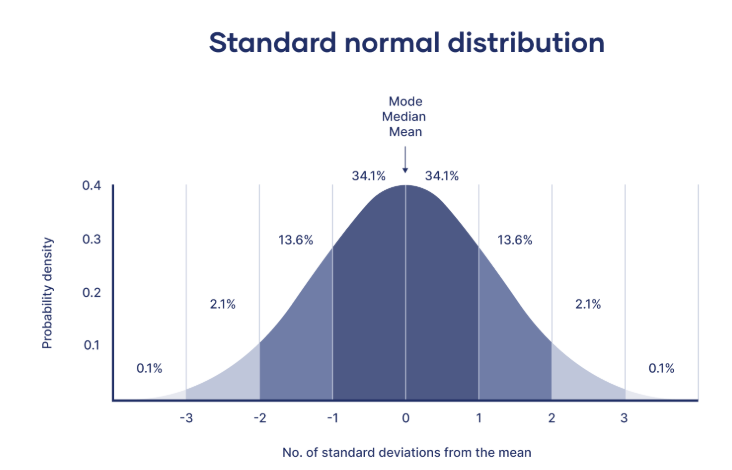

In [ ]:
# f = w · x + b (dot multiply)

W = torch.randn((27, 27))# define the weights now
xenc @ W  # @: matrix multiplication operator in Pytorch
# xenc(5, 27) @ W(27, 27) -> (5, 27) 

The result of **`xenc @ W`** is telling us for every one of 27 neurons that we created, what is the firing rate of those neurons on every one of those five examples.

Now we are going to interpret them as **`log counts`**, then element wise **`exponentiate`** these numbers

In [ ]:
(xenc @ W).exp() # negative ones turn into ones lower than 1, positive ones are greater than 1
logits = xenc @ W # log-counts
counts = logits.exp() # equivalent N(the counts matrix)
probs = counts / counts.sum(1, keepdim=True) # normalized
probs

**`Softmax`** is a very often used layer in neural net, takes logits exponentiates them and normalizes them, it's a **`normalization function`**

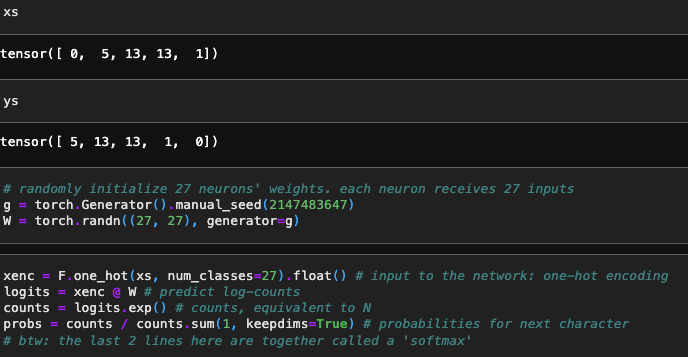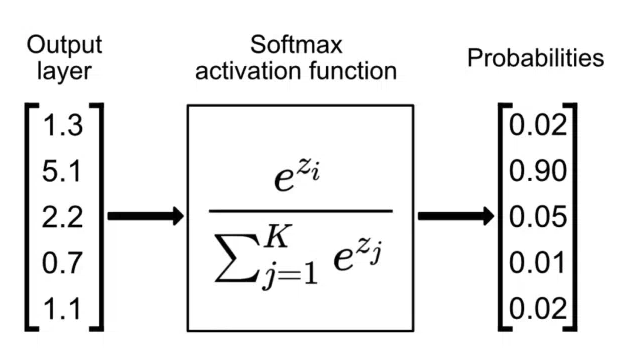

We can backpropagate through them.

In [ ]:
# randomly initialize 27 neurons' weights. each neuron receives 27 inputs
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g)
xenc = F.one_hot(xs, num_classes=27).float() # input to the network: one-hot encoding
logits = xenc @ W # predict log-counts
counts = logits.exp() # counts, equivalent to N
probs = counts / counts.sum(1, keepdims=True) # probabilities for next character
# btw: the last 2 lines here are together called a 'softmax'
probs.shape

In [ ]:

nlls = torch.zeros(5)
for i in range(5):
  # i-th bigram:
  x = xs[i].item() # input character index
  y = ys[i].item() # label character index
  print('--------')
  print(f'bigram example {i+1}: {itos[x]}{itos[y]} (indexes {x},{y})')
  print('input to the neural net:', x)
  print('output probabilities from the neural net:', probs[i])
  print('label (actual next character):', y)
  p = probs[i, y]
  print('probability assigned by the net to the the correct character:', p.item())
  logp = torch.log(p)
  print('log likelihood:', logp.item())
  nll = -logp
  print('negative log likelihood:', nll.item())
  nlls[i] = nll

print('=========')
print('average negative log likelihood, i.e. loss =', nlls.mean().item())

Time for Optimization.

In [ ]:
xs

In [ ]:
ys

In [ ]:
# randomly initialize 27 neurons' weights. each neuron receives 27 inputs
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)

## Forward Pass

In [ ]:
# forward pass
xenc = F.one_hot(xs, num_classes=27).float() # input to the network: one-hot encoding
logits = xenc @ W # predict log-counts
counts = logits.exp() # counts, equivalent to N
probs = counts / counts.sum(1, keepdims=True) # probabilities for next character

In [ ]:
#probs[0,5], probs[1,13], probs[2,13], probs[3,1], probs[4,0]
probs[torch.arange(5), ys] # gives the same result as the line above

In [ ]:
# calculate the loss with negative log likelihood (classification)
loss = -probs[torch.arange(5), ys].log().mean()


## Backward Pass

In [ ]:
# set to zero the gradient
W.grad = None
loss.backward()

In [ ]:
W.data += 0.01 * W.grad # it has values inside now 


## Tidy up!!!

In [ ]:
# create the dataset
xs, ys = [],[]
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)
xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()
print('number of examples: ', num)

# initialize the 'network'
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27,27), generator=g, requires_grad=True)

In [ ]:
# gradient descent
for k in range(100):
    # forward pass
    xenc = F.one_hot(xs,num_classes=27).float() # input to the network: one-hot encoding
    logits = xenc @ W # predict log-counts
    counts = logits.exp() # counts, equivalent to N
    probs = counts / counts.sum(1, keepdim=True) # probabilities for next char
    loss = -probs[torch.arange(num), ys].log().mean()
    print(loss.item())

    #backward pass
    W.grad = None # set to zeros the gradient
    loss.backward()

    #update
    W.data += -0.1 * W.grad